In [1]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.1 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="construction-ppe.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="wasp_ppe_full_v2"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=construction-ppe.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640

In [3]:
model = YOLO("/content/runs/detect/wasp_ppe_full_v2/weights/best.pt")

metrics = model.val(data="construction-ppe.yaml")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,007,793 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2536.0±932.7 MB/s, size: 181.3 KB)
val: Scanning /content/datasets/construction-ppe/labels/val.cache... 143 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 143/143 50.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.0it/s 4.6s
                   all        143       1172      0.598       0.53       0.57      0.279
                helmet        107        201      0.855      0.836      0.857      0.448
                gloves         68        136      0.856      0.779      0.827      0.375
                  vest        109        171      0.796      0.819      0.837      0.523
                 boots         64        151      0.777      0.709      0.806      0.461
               goggles         44 

In [7]:
model.predict(
    source="/content/4-person-construction-crew-standing-in-front-of-house-F9YJFP.jpg",
    conf=0.5,
    save=True
)


image 1/1 /content/4-person-construction-crew-standing-in-front-of-house-F9YJFP.jpg: 480x640 4 helmets, 4 vests, 1 boots, 4 Persons, 44.9ms
Speed: 2.9ms preprocess, 44.9ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'helmet', 1: 'gloves', 2: 'vest', 3: 'boots', 4: 'goggles', 5: 'none', 6: 'Person', 7: 'no_helmet', 8: 'no_goggle', 9: 'no_gloves', 10: 'no_boots'}
 obb: None
 orig_img: array([[[201, 186, 170],
         [199, 183, 176],
         [196, 179, 188],
         ...,
         [154, 148, 135],
         [154, 148, 135],
         [154, 148, 135]],
 
        [[195, 180, 164],
         [193, 177, 170],
         [192, 173, 182],
         ...,
         [170, 152, 145],
         [170, 152, 145],
         [170, 152, 145]],
 
        [[201, 185, 169],
         [198, 183, 174],
         [196, 178, 185],
         ...,
         [175, 151, 151],
         [175, 151, 151],
         [175, 151, 151]],
 
        ...,
 
        [[  1,   1,   1],
         [  1,   1,   1],
         [  1,   1,   1],
         ...,
         [  1,   1,   1],
         [  1,   1,   1],
 

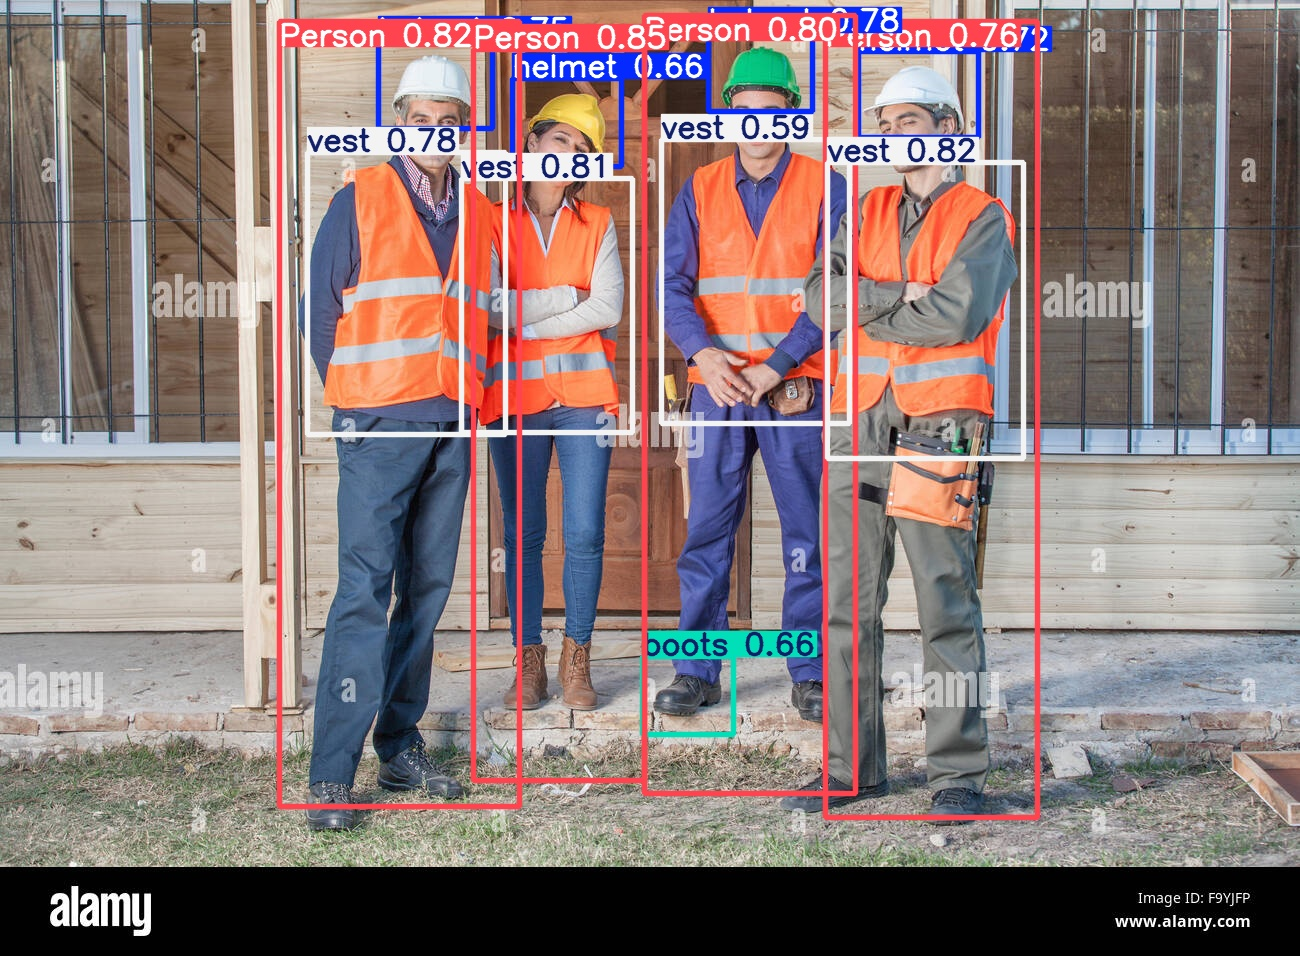

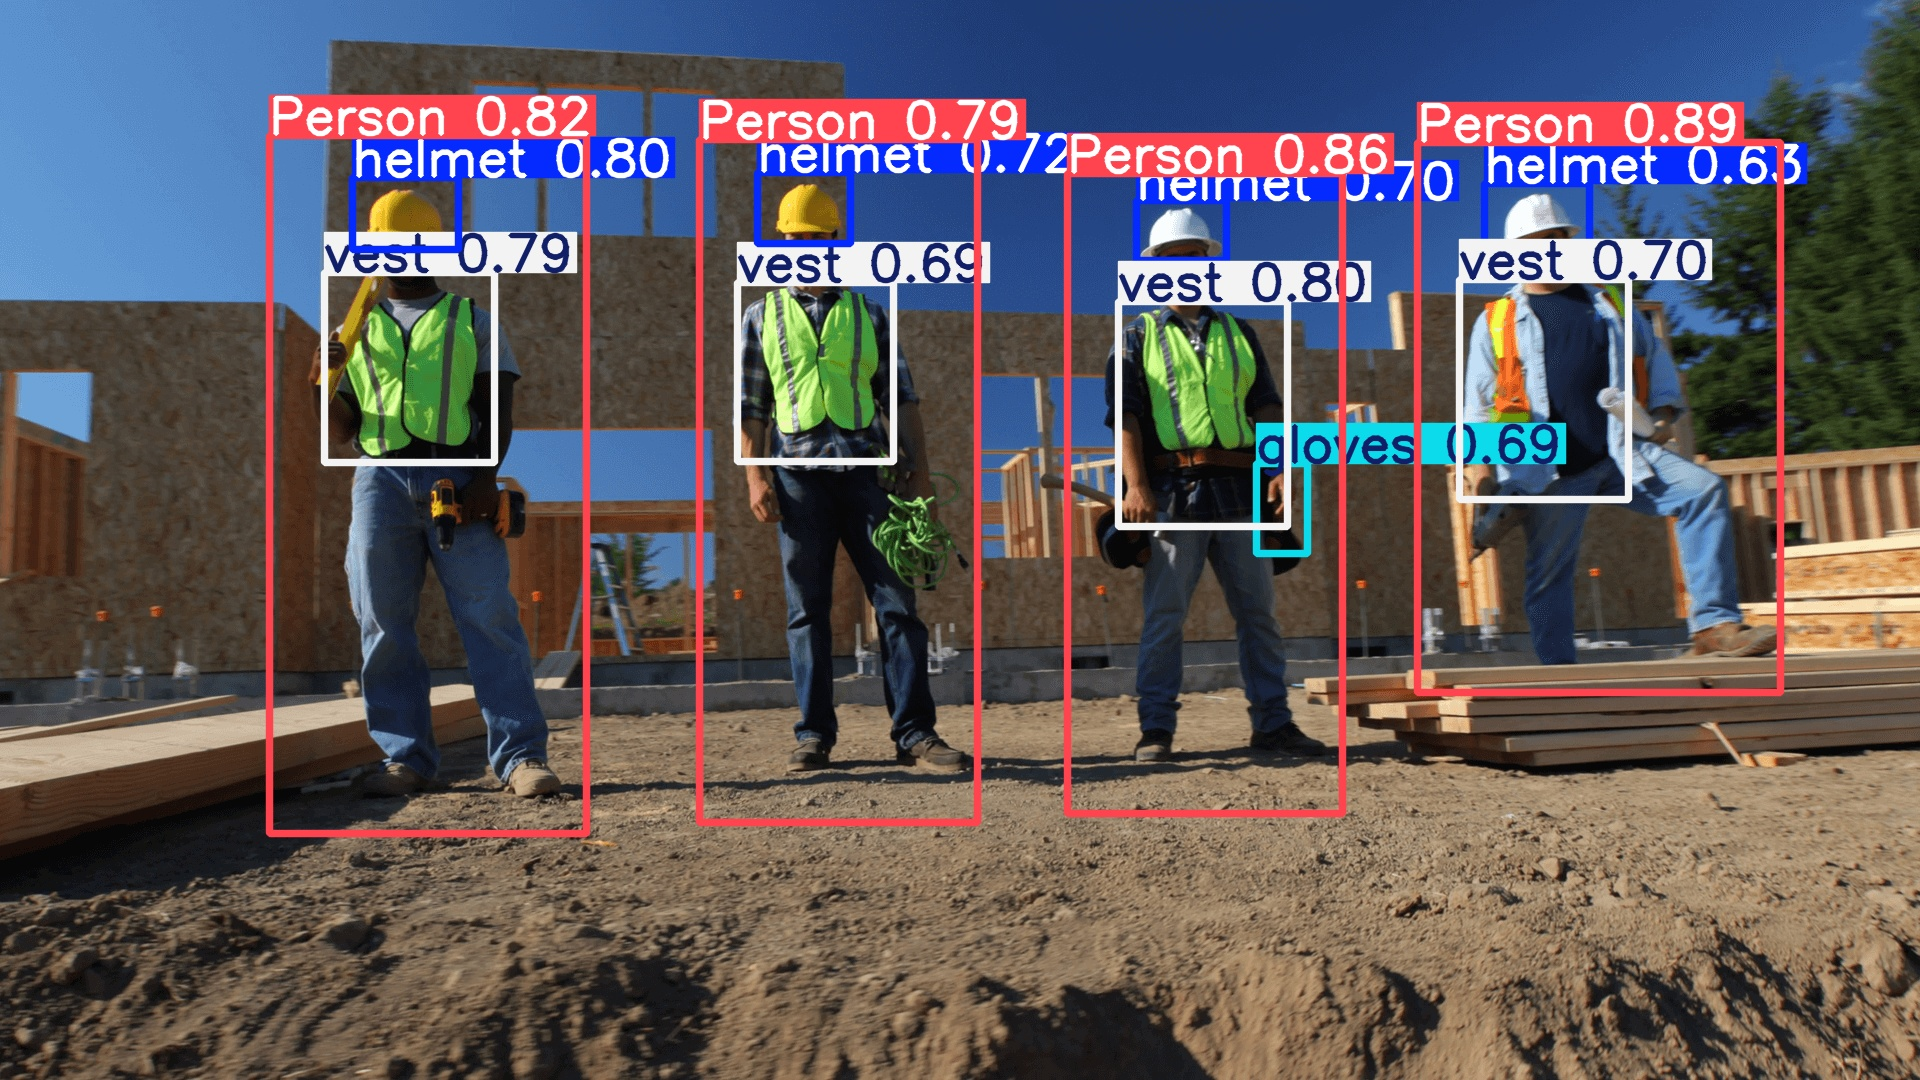

In [8]:
import glob
from IPython.display import Image, display

result_images = glob.glob("/content/runs/detect/predict/*")

for img in result_images[:5]:
    display(Image(filename=img))

In [9]:
from google.colab import files

files.download("/content/runs/detect/wasp_ppe_full_v2/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>